<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/5.2-model-training-with-agumentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.utils.extmath import device
# Preprocesamiento y obtencion de conjuntos para entrenamiento, test, validacion.
#--------------------------------------------------------------------------------
import random
# Conectar a Google Drive

# ROOT_DIR = '/content/drive/MyDrive/ravdess_images_02'  # Ajustar a tu ruta :)
FAST_ROOT_DIR = '/content/ravdess_and_crema_images'
# Configuración del dispositivo (GPU si está disponible, de lo contrario CPU)
# Se recomienda usar la GPU que ofrece Google Colab para acelerar el entrenamiento
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# --- 1. DATASET PERSONALIZADO (Reemplaza a ImageFolder) ---
class CustomAudioImageDataset(Dataset):
    def __init__(self, file_paths, class_to_idx, transform=None):
        self.file_paths = file_paths
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        # Data Handling: La emoción es el nombre de la carpeta padre
        emotion = os.path.basename(os.path.dirname(img_path))
        label = self.class_to_idx[emotion]

        # PIL para cargar la imagen, convertir a RGB (ResNet/EfficientNet lo requieren)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label


# --- 2. FUNCIÓN DE CARGA SIN SPEAKER LEAKAGE (SPEAKER-INDEPENDENT) ---
def get_dataloaders(base_dir, feature_type, batch_size=32):
    FEATURE_DIR = os.path.join(base_dir, feature_type)

    if not os.path.exists(FEATURE_DIR):
        print(f"Error: No se encontró {FEATURE_DIR}")
        return None, None, None, None

    class_names = sorted(os.listdir(FEATURE_DIR))
    class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}
    print(f"Emociones detectadas: {class_names}")

    # Diccionario para agrupar TODOS los archivos (originales y aumentados) por ID de ACTOR
    actor_dict = {}

    def extract_actor_id(filename):
        """ Extrae el ID del actor dependiendo del dataset (RAVDESS o CREMA-D) """
        base = filename.replace('noise_', '').replace('shift_', '')
        if base.startswith('r_'):
            # Ej: r_03-01-05-01-01-01-01.png -> Toma el último '01'
            return "ravdess_" + base.split('-')[-1].replace('.png', '')
        elif base.startswith('c_'):
            # Ej: c_1001_DFA_ANG_XX.png -> Toma '1001'
            return "crema_" + base.split('_')[1]
        return "unknown_actor"

    for emotion in class_names:
        emo_dir = os.path.join(FEATURE_DIR, emotion)
        if not os.path.isdir(emo_dir): continue

        for f in os.listdir(emo_dir):
            if not f.endswith('.png'): continue
            full_path = os.path.join(emo_dir, f)

            actor_id = extract_actor_id(f)

            if actor_id not in actor_dict:
                actor_dict[actor_id] = []
            actor_dict[actor_id].append(full_path)

    # Split de los ACTORES (80% Actores a Train, 10% a Val, 10% a Test)
    unique_actors = list(actor_dict.keys())
    random.seed(42)
    random.shuffle(unique_actors)

    train_split = int(0.8 * len(unique_actors))
    val_split = int(0.9 * len(unique_actors))

    train_actors = unique_actors[:train_split]
    val_actors = unique_actors[train_split:val_split]
    test_actors = unique_actors[val_split:]

    print(f"\nTotal Actores detectados: {len(unique_actors)}")
    print(f"Actores en Train: {len(train_actors)} | Val: {len(val_actors)} | Test: {len(test_actors)}")

    train_paths, val_paths, test_paths = [], [], []

    # TRAIN: Recibe TODOS los archivos de sus actores asignados (Original + Ruido + Shift)
    for actor in train_actors:
        train_paths.extend(actor_dict[actor])

    # VAL y TEST: Solo reciben los archivos ORIGINALES de sus actores asignados
    for actor in val_actors:
        for path in actor_dict[actor]:
            if 'noise_' not in path and 'shift_' not in path:
                val_paths.append(path)

    for actor in test_actors:
        for path in actor_dict[actor]:
            if 'noise_' not in path and 'shift_' not in path:
                test_paths.append(path)

    print(f"\nEl tamaño de los sets (imágenes) es:")
    print(f"Entrenamiento (Con Augmentation): {len(train_paths)}")
    print(f"Validación (Solo Originales): {len(val_paths)}")
    print(f"Test (Solo Originales): {len(test_paths)}")

    # Transforms y DataLoaders
    data_transforms = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    train_dataset = CustomAudioImageDataset(train_paths, class_to_idx, data_transforms)
    val_dataset = CustomAudioImageDataset(val_paths, class_to_idx, data_transforms)
    test_dataset = CustomAudioImageDataset(test_paths, class_to_idx, data_transforms)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader, class_names

## CNN VS FINE-TUNING VS RANDOM FOREST CON DATA AUGMENTATION


## Introducción

Implementando PyTorch y Torchvision, compararemos el desempeño de un modelo CNN pre-entrenado, un modelo con Fine-Tuning y un modelo Random Forest para la tarea de clasificación de imágenes.

El input para probar nuestros modelos será un archivo de audio nuevo, grabado por nosotros mismos. Este clip será primero filtrado, recortado y convertido en un espectrograma. Los parámetros de dicha transformación deberán ajustarse rigurosamente al formato de entrada que hemos configurado para nuestros modelos.

Para probar el modelo seleccionado y guardado, se destinará una Web App donde el usuario podrá subir su propio clip de audio; el sistema se encargará de procesarlo automáticamente y mostrar los resultados de las predicciones de cada modelo.

In [1]:
# importando librerias necesarias

import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms, models
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from torch.cuda.amp import GradScaler, autocast # Para eficiencia en memoria
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Copiamos la carpeta entera de features desde Drive al disco ultrarrápido de Colab
#!cp -r /content/drive/MyDrive/ravdess_images_02/ /content/features_local

# Opcional: Si tienes un archivo .zip en Drive, es AÚN MÁS RÁPIDO copiar el .zip y descomprimirlo localmente:
!cp /content/drive/MyDrive/ravdess_and_crema_images_224_224.zip /content/
!unzip -q /content/ravdess_and_crema_images_224_224.zip -d /content/ravdess_and_crema_images

In [22]:
from sklearn.utils.extmath import device
# Preprocesamiento y obtencion de conjuntos para entrenamiento, test, validacion.
#--------------------------------------------------------------------------------
import random
# Conectar a Google Drive

# ROOT_DIR = '/content/drive/MyDrive/ravdess_images_02'  # Ajustar a tu ruta :)
FAST_ROOT_DIR = '/content/ravdess_and_crema_images'
# Configuración del dispositivo (GPU si está disponible, de lo contrario CPU)
# Se recomienda usar la GPU que ofrece Google Colab para acelerar el entrenamiento
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# --- 1. DATASET PERSONALIZADO (Reemplaza a ImageFolder) ---
class CustomAudioImageDataset(Dataset):
    def __init__(self, file_paths, class_to_idx, transform=None):
        self.file_paths = file_paths
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        # Data Handling: La emoción es el nombre de la carpeta padre
        emotion = os.path.basename(os.path.dirname(img_path))
        label = self.class_to_idx[emotion]

        # PIL para cargar la imagen, convertir a RGB (ResNet/EfficientNet lo requieren)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label


# --- 2. FUNCIÓN DE CARGA SIN SPEAKER LEAKAGE (SPEAKER-INDEPENDENT) ---
def get_dataloaders(base_dir, feature_type, batch_size=32):
    FEATURE_DIR = os.path.join(base_dir, feature_type)

    if not os.path.exists(FEATURE_DIR):
        print(f"Error: No se encontró {FEATURE_DIR}")
        return None, None, None, None

    class_names = sorted(os.listdir(FEATURE_DIR))
    class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}
    print(f"Emociones detectadas: {class_names}")

    # Diccionario para agrupar TODOS los archivos (originales y aumentados) por ID de ACTOR
    actor_dict = {}

    def extract_actor_id(filename):
        """ Extrae el ID del actor dependiendo del dataset (RAVDESS o CREMA-D) """
        base = filename.replace('noise_', '').replace('shift_', '')
        if base.startswith('r_'):
            # Ej: r_03-01-05-01-01-01-01.png -> Toma el último '01'
            return "ravdess_" + base.split('-')[-1].replace('.png', '')
        elif base.startswith('c_'):
            # Ej: c_1001_DFA_ANG_XX.png -> Toma '1001'
            return "crema_" + base.split('_')[1]
        return "unknown_actor"

    for emotion in class_names:
        emo_dir = os.path.join(FEATURE_DIR, emotion)
        if not os.path.isdir(emo_dir): continue

        for f in os.listdir(emo_dir):
            if not f.endswith('.png'): continue
            full_path = os.path.join(emo_dir, f)

            actor_id = extract_actor_id(f)

            if actor_id not in actor_dict:
                actor_dict[actor_id] = []
            actor_dict[actor_id].append(full_path)

    # Split de los ACTORES (80% Actores a Train, 10% a Val, 10% a Test)
    unique_actors = list(actor_dict.keys())
    random.seed(42)
    random.shuffle(unique_actors)

    train_split = int(0.8 * len(unique_actors))
    val_split = int(0.9 * len(unique_actors))

    train_actors = unique_actors[:train_split]
    val_actors = unique_actors[train_split:val_split]
    test_actors = unique_actors[val_split:]

    print(f"\nTotal Actores detectados: {len(unique_actors)}")
    print(f"Actores en Train: {len(train_actors)} | Val: {len(val_actors)} | Test: {len(test_actors)}")

    train_paths, val_paths, test_paths = [], [], []

    # TRAIN: Recibe TODOS los archivos de sus actores asignados (Original + Ruido + Shift)
    for actor in train_actors:
        train_paths.extend(actor_dict[actor])

    # VAL y TEST: Solo reciben los archivos ORIGINALES de sus actores asignados
    for actor in val_actors:
        for path in actor_dict[actor]:
            if 'noise_' not in path and 'shift_' not in path:
                val_paths.append(path)

    for actor in test_actors:
        for path in actor_dict[actor]:
            if 'noise_' not in path and 'shift_' not in path:
                test_paths.append(path)

    print(f"\nEl tamaño de los sets (imágenes) es:")
    print(f"Entrenamiento (Con Augmentation): {len(train_paths)}")
    print(f"Validación (Solo Originales): {len(val_paths)}")
    print(f"Test (Solo Originales): {len(test_paths)}")

    # Transforms y DataLoaders
    data_transforms = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    train_dataset = CustomAudioImageDataset(train_paths, class_to_idx, data_transforms)
    val_dataset = CustomAudioImageDataset(val_paths, class_to_idx, data_transforms)
    test_dataset = CustomAudioImageDataset(test_paths, class_to_idx, data_transforms)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader, class_names

In [23]:
# Print root_dir content:
print(os.listdir(FAST_ROOT_DIR))

['mfcc', 'mel_spec']


In [24]:
get_dataloaders(FAST_ROOT_DIR, 'mel_spec', batch_size=32)

Emociones detectadas: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

Total Actores detectados: 115
Actores en Train: 92 | Val: 11 | Test: 12

El tamaño de los sets (imágenes) es:
Entrenamiento (Con Augmentation): 7434
Validación (Solo Originales): 808
Test (Solo Originales): 896


(<torch.utils.data.dataloader.DataLoader at 0x78f2d2264530>,
 ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised'])

In [25]:
def build_model(model_name='resnet', num_classes=7, freeze_base=True):

  """
  Funcion Instanciadora de modelos pre-entrenados los mas optimos para espetrogramas y
  mfcc
  """
  # Para ResNet18
  if model_name == 'resnet18':
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if freeze_base:
      for param in model.parameters():
        param.requires_grad = False
      # Descongelar el ultimo bloque convolucional
      for param in model.layer4.parameters():
        param.requires_grad = True

    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(nn.Dropout(p=0.5), nn.Linear(num_ftrs, num_classes))

  # Para EfficientNetB0
  elif model_name == 'efficientnet_b0':
      model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
      if freeze_base:
          for param in model.parameters(): param.requires_grad = False
          # Descongelar último bloque (features.8)
          for param in model.features[8].parameters(): param.requires_grad = True
      num_ftrs = model.classifier[1].in_features
      model.classifier = nn.Sequential(nn.Dropout(p=0.5), nn.Linear(num_ftrs, num_classes))

  # Para EfficientNetB0
  elif model_name == 'densenet121':
      model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
      if freeze_base:
          for param in model.parameters(): param.requires_grad = False
          # Descongelar último bloque denso
          for param in model.features.denseblock4.parameters(): param.requires_grad = True
      num_ftrs = model.classifier.in_features
      model.classifier = nn.Sequential(nn.Dropout(p=0.5), nn.Linear(num_ftrs, num_classes))

  else:
      raise ValueError("Modelo no soportado")
  return model.to(device)

In [11]:
from torch.overrides import TorchFunctionMode
from functools import total_ordering

# Entrenamiento mediante cliclo optimizado (Aqui es donde realmente usamos la GPU)
MODELS_DIR = '/content/drive/MyDrive/models_with_model_factory'

def train_model(model, train_loader, val_loader, feature_type, epochs=15, lr=1e-5):
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-3)

  scaler = torch.amp.GradScaler('cuda')
  best_val_loss = float('inf')

  # --- INICIALIZACIÓN DEL EARLY STOP ---
  patience = 4
  trigger_times = 0
  # -------------------------------------

  os.makedirs(MODELS_DIR, exist_ok=True)
  best_model_path = os.path.join(MODELS_DIR, f'best_model_for_{feature_type}')

  print(f"Iniciando entrenamiento para la feature: {feature_type}")

  for epoch in range(epochs):
      model.train()
      running_loss, correct, total = 0.0, 0 , 0

      for inputs, labels in train_loader:
          inputs, labels = inputs.to(device), labels.to(device)
          optimizer.zero_grad()
          with torch.amp.autocast('cuda'):
              outputs = model(inputs)
              loss = criterion(outputs, labels)
          scaler.scale(loss).backward()
          scaler.step(optimizer)
          scaler.update()

          running_loss += loss.item() * inputs.size(0)
          _, predicted = torch.max(outputs, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()

      train_loss = running_loss / total
      train_acc = correct / total

      # --- FASE DE VALIDACIÓN ---
      model.eval()
      val_running_loss, val_correct, val_total = 0.0, 0, 0

      with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

      # 1. Calculamos los promedios finales de la época
      val_loss = val_running_loss / val_total
      val_acc = val_correct / val_total

      print(f"Época {epoch+1}/{epochs} | Loss Entr: {train_loss:.4f} Acc Entr: {train_acc:.4f} | Loss Val: {val_loss:.4f} Acc Val: {val_acc:.4f}")

      # 2. Lógica de Early Stopping y Guardado (FUERA del bucle de datos)
      if val_loss < best_val_loss:
          best_val_loss = val_loss
          torch.save(model.state_dict(), best_model_path)
          trigger_times = 0  # Reset si hay mejora
          print(f"--> ¡Mejora detectada! Modelo guardado.")
      else:
          trigger_times += 1
          print(f"--> Sin mejora. Strike {trigger_times}/{patience}")
          if trigger_times >= patience:
              print(f"Early stopping ejecutado en la época {epoch+1}. Deteniendo entrenamiento.")
              break

  print(f"Entrenamiento completado. Mejor modelo guardado como '{best_model_path}'\n")
  return best_model_path

In [30]:
TARGET_FEATURE = 'mel_spec'
MODEL_ARCHITECTURE = 'efficientnet_b0' # Aqui puedes probar con los modelos diponibles: 'resnet18', 'densenet121, efficientnet_b0'

# 1. Cargamos los datos
train_loader, val_loader, test_loader, class_names = get_dataloaders(
    base_dir=FAST_ROOT_DIR,
    feature_type=TARGET_FEATURE,
    batch_size=64 # Bajamos un poco el batch_size por si usamos DenseNet
)

# 2. Construir el modelo dinámicamente:
model = build_model(model_name=MODEL_ARCHITECTURE, num_classes=len(class_names), freeze_base=True)

# 3. Modificamos dinámicamente la ruta de guardado para no sobrescribir experimentos

experiment_name = f"{TARGET_FEATURE}_{MODEL_ARCHITECTURE}"

# 4. Ejecutar el entrenamiento (FASE 1: Capas superiores):
print(f"--- INICIANDO FASE 1: Entrenando clasificador de {MODEL_ARCHITECTURE} ---")
best_model_path = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    feature_type=experiment_name,
    epochs=15,
    lr=1e-4 # Un LR un poco más alto para arrancar
)

# 5. Opcional: FASE 2 (Fine-Tuning Profundo)
# Descongelamos TODO el modelo para que los filtros aprendan formas de audio
print(f"\n--- INICIANDO FASE 2: Fine-Tuning profundo ---")
model.load_state_dict(torch.load(best_model_path)) # Cargar el mejor modelo de Fase 1
for param in model.parameters():
    param.requires_grad = True

best_model_path_phase2 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    feature_type=f"{experiment_name}_unfrozen",
    epochs=40,
    lr=1e-5 # LR súper bajo para no destruir los pesos preentrenados
)

Emociones detectadas: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

Total Actores detectados: 115
Actores en Train: 92 | Val: 11 | Test: 12

El tamaño de los sets (imágenes) es:
Entrenamiento (Con Augmentation): 7434
Validación (Solo Originales): 808
Test (Solo Originales): 896
--- INICIANDO FASE 1: Entrenando clasificador de efficientnet_b0 ---
Iniciando entrenamiento para la feature: mel_spec_efficientnet_b0
Época 1/15 | Loss Entr: 1.8036 Acc Entr: 0.2720 | Loss Val: 1.7229 Acc Val: 0.3379
--> ¡Mejora detectada! Modelo guardado.
Época 2/15 | Loss Entr: 1.6328 Acc Entr: 0.3617 | Loss Val: 1.6505 Acc Val: 0.3577
--> ¡Mejora detectada! Modelo guardado.
Época 3/15 | Loss Entr: 1.5484 Acc Entr: 0.4017 | Loss Val: 1.5958 Acc Val: 0.3688
--> ¡Mejora detectada! Modelo guardado.
Época 4/15 | Loss Entr: 1.4888 Acc Entr: 0.4255 | Loss Val: 1.5589 Acc Val: 0.3861
--> ¡Mejora detectada! Modelo guardado.
Época 5/15 | Loss Entr: 1.4542 Acc Entr: 0.4395 | Loss Val: 1.5213 

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(model, model_path, test_loader, class_names):
    """
    Carga el mejor modelo guardado y calcula las métricas de rendimiento en el test set.
    """
    #print(f"Cargando los pesos del mejor modelo desde: {model_path}")
    # Cargamos los pesos de la época con menor Loss de Validación
    model.load_state_dict(torch.load(model_path))
    model.eval() # Modo evaluación: desactiva Dropout y Batch Normalization

    all_preds = []
    all_labels = []

    # Desactivamos el cálculo de gradientes para ahorrar memoria (GPU allocation)
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            # Movemos los tensores a la CPU para poder usarlos con Scikit-Learn
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 1. Reporte de Clasificación (F1-Score, Precision, Recall, Accuracy)
    print("\n" + "="*50)
    print("REPORTE DE CLASIFICACIÓN (CONJUNTO DE PRUEBA)")
    print("="*50)
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # 2. Matriz de Confusión Visual
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de Confusión - Evaluación de modelo')
    plt.ylabel('Etiqueta Verdadera')
    plt.xlabel('Predicción del Modelo')
    plt.show()
    print(f"Matriz de confusion plana: \n {cm}")



Evaluando modelo: best_model_for_mel_spec_efficientnet_b0_unfrozen


REPORTE DE CLASIFICACIÓN (CONJUNTO DE PRUEBA)
              precision    recall  f1-score   support

       angry       0.64      0.58      0.61       144
     disgust       0.60      0.42      0.50       144
     fearful       0.46      0.49      0.47       144
       happy       0.46      0.62      0.53       144
     neutral       0.51      0.62      0.56       144
         sad       0.57      0.35      0.43       144
   surprised       0.49      0.81      0.61        32

    accuracy                           0.52       896
   macro avg       0.53      0.56      0.53       896
weighted avg       0.54      0.52      0.52       896



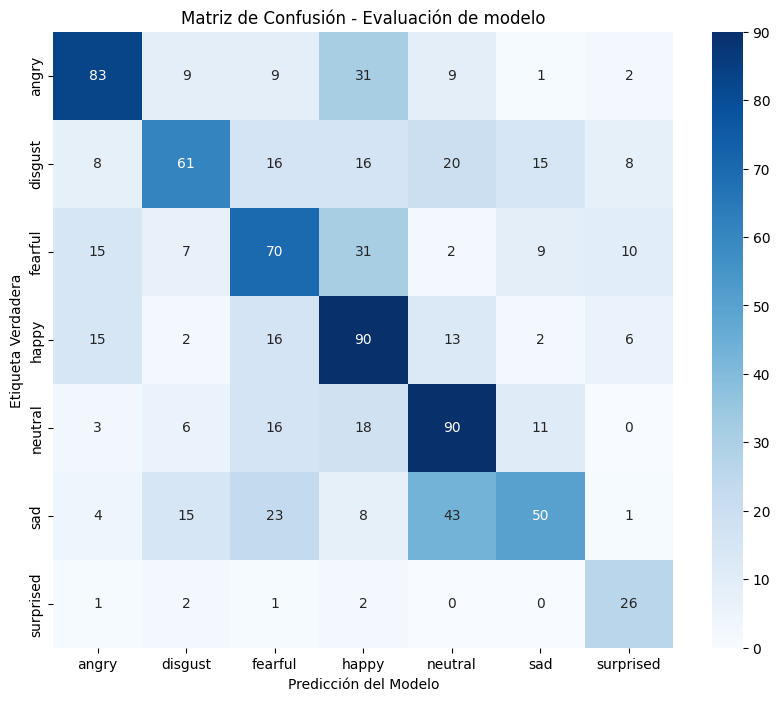

Matriz de confusion plana: 
 [[83  9  9 31  9  1  2]
 [ 8 61 16 16 20 15  8]
 [15  7 70 31  2  9 10]
 [15  2 16 90 13  2  6]
 [ 3  6 16 18 90 11  0]
 [ 4 15 23  8 43 50  1]
 [ 1  2  1  2  0  0 26]]


In [31]:

# Define la ruta específica que vas a evaluar ahora
current_path = '/content/drive/MyDrive/models_with_model_factory/best_model_for_mel_spec_efficientnet_b0_unfrozen'
# Prints
print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")
#Llamado a la funcion evaluadora
evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)



Evaluando modelo: best_model_for_mfcc_efficientnet_b0_unfrozen


REPORTE DE CLASIFICACIÓN (CONJUNTO DE PRUEBA)
              precision    recall  f1-score   support

       angry       0.77      0.67      0.72       147
     disgust       0.49      0.39      0.43       160
     fearful       0.46      0.44      0.45       139
       happy       0.53      0.44      0.48       165
     neutral       0.44      0.64      0.52       123
         sad       0.50      0.57      0.53       143
   surprised       0.69      0.88      0.78        51

    accuracy                           0.54       928
   macro avg       0.56      0.57      0.56       928
weighted avg       0.54      0.54      0.53       928



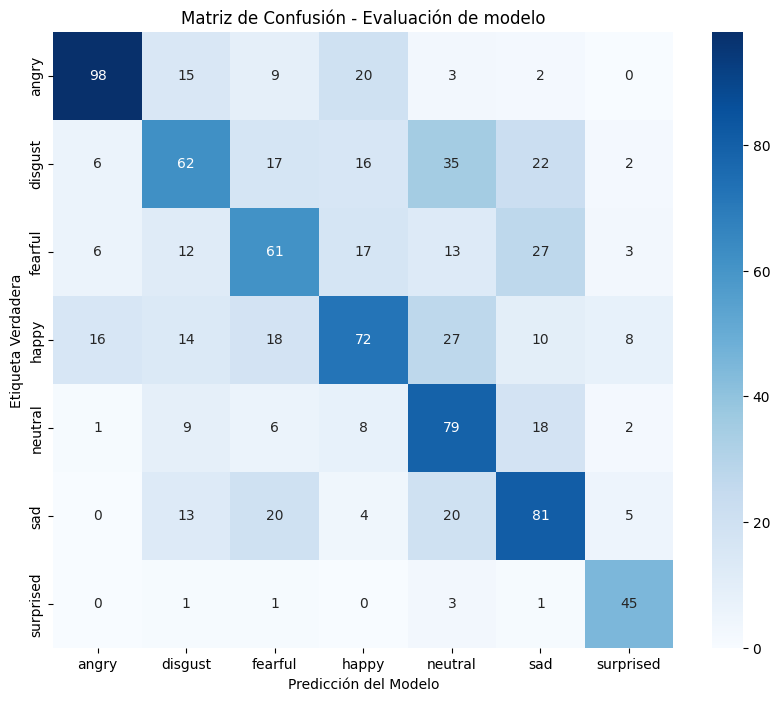

Matriz de confusion plana: 
 [[98 15  9 20  3  2  0]
 [ 6 62 17 16 35 22  2]
 [ 6 12 61 17 13 27  3]
 [16 14 18 72 27 10  8]
 [ 1  9  6  8 79 18  2]
 [ 0 13 20  4 20 81  5]
 [ 0  1  1  0  3  1 45]]


In [19]:
current_path = '/content/drive/MyDrive/models_with_model_factory/best_model_for_mfcc_efficientnet_b0_unfrozen'

print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")

evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)


Evaluando modelo: best_model_for_mfcc_densenet121_unfrozen


REPORTE DE CLASIFICACIÓN (CONJUNTO DE PRUEBA)
              precision    recall  f1-score   support

       angry       0.77      0.57      0.66       144
     disgust       0.41      0.33      0.37       144
     fearful       0.48      0.33      0.40       144
       happy       0.38      0.55      0.45       144
     neutral       0.44      0.58      0.50       144
         sad       0.46      0.39      0.42       144
   surprised       0.43      0.72      0.54        32

    accuracy                           0.47       896
   macro avg       0.48      0.50      0.48       896
weighted avg       0.49      0.47      0.47       896



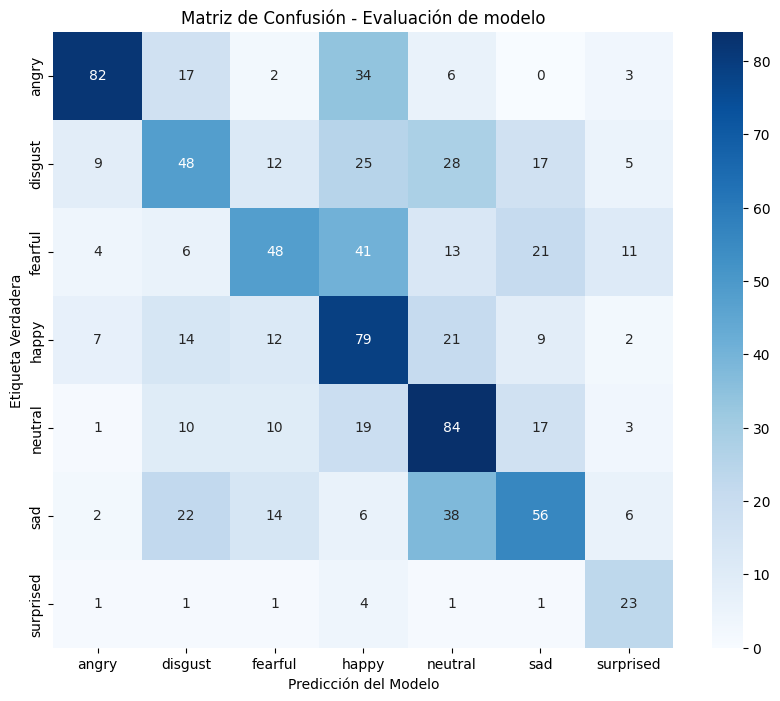

Matriz de confusion plana: 
 [[82 17  2 34  6  0  3]
 [ 9 48 12 25 28 17  5]
 [ 4  6 48 41 13 21 11]
 [ 7 14 12 79 21  9  2]
 [ 1 10 10 19 84 17  3]
 [ 2 22 14  6 38 56  6]
 [ 1  1  1  4  1  1 23]]


In [27]:
current_path = '/content/drive/MyDrive/models_with_model_factory/best_model_for_mfcc_densenet121_unfrozen'

print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")

evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)

In [ ]:
current_path = '/content/drive/MyDrive/saved_models_ResNet/best_model_for_delta'

print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")

evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)

In [ ]:
current_path = '/content/drive/MyDrive/saved_models_ResNet/best_model_for_delta2'

print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")

evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)